### Objective
In this worksheet, I implemented two image classification approaches using the FruitsInAmazon dataset:

1. An improved Convolutional Neural Network (CNN) built from scratch using:
   - data augmentation,
   - batch normalization,
   - dropout.

2. A transfer learning model using the pre-trained VGG16 network.

Both models were trained and evaluated on the fruits dataset, and their performance was compared using test accuracy and classification reports.

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image, UnidentifiedImageError
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [2]:
train_dir = r"FruitinAmazon/train"
test_dir = r"FruitinAmazon/test"

img_height = 224
img_width = 224
image_size = (img_height, img_width)

batch_size = 16
seed = 1337
validation_split = 0.2

# Task 1 - Improved CNN from Scratch

## Step 1: Verify Dataset Directory

The first step is to verify whether the training directory contains the expected class folders.

In [3]:
class_names = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [4]:
def check_corrupted_images(data_dir):
    corrupted_images = []

    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)

        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)

                if not img_name.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".webp")):
                    continue

                try:
                    with Image.open(img_path) as img:
                        img.verify()
                except (IOError, UnidentifiedImageError, OSError, SyntaxError):
                    corrupted_images.append(img_path)

    if corrupted_images:
        print("\nCorrupted Images Found:")
        for img in corrupted_images:
            print(img)
    else:
        print("\nNo corrupted images found.")

    return corrupted_images

train_corrupted = check_corrupted_images(train_dir)
test_corrupted = check_corrupted_images(test_dir)


No corrupted images found.

No corrupted images found.


## Step 3: Check Class Distribution

A balanced dataset helps the model learn fairly across all categories. If one class has many more images than others, the model may become biased toward that class.

In [5]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


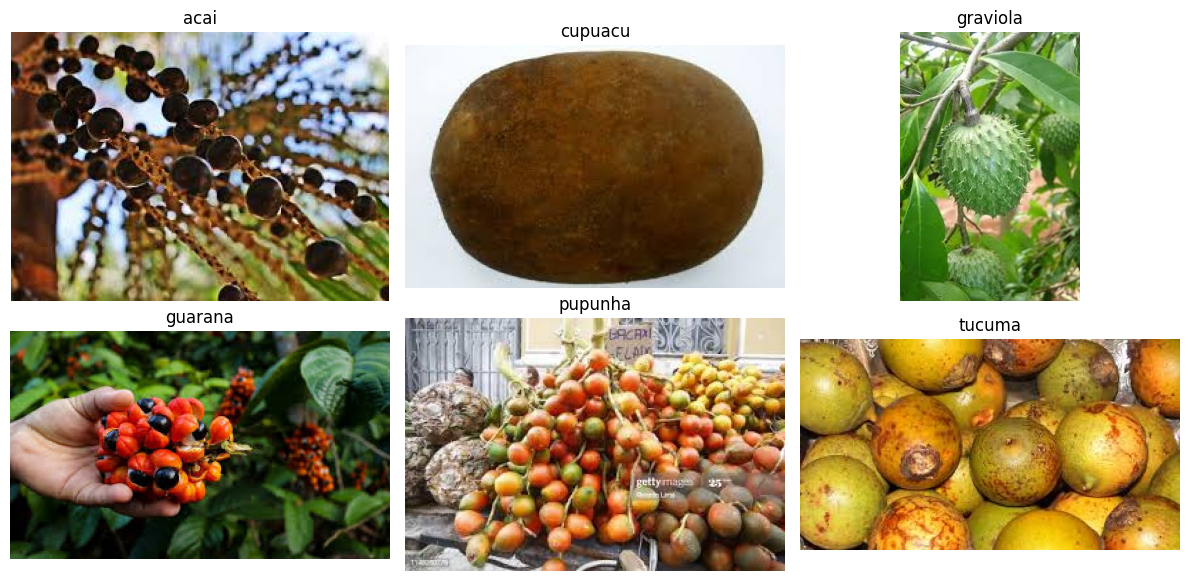

In [6]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith((".png", ".jpg", ".jpeg"))
        ]

        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < num_classes:
        img = plt.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="training",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="validation",
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class Names:", class_names)
print("Number of Classes:", num_classes)

Found 90 files belonging to 6 classes.


Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class Names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of Classes: 6


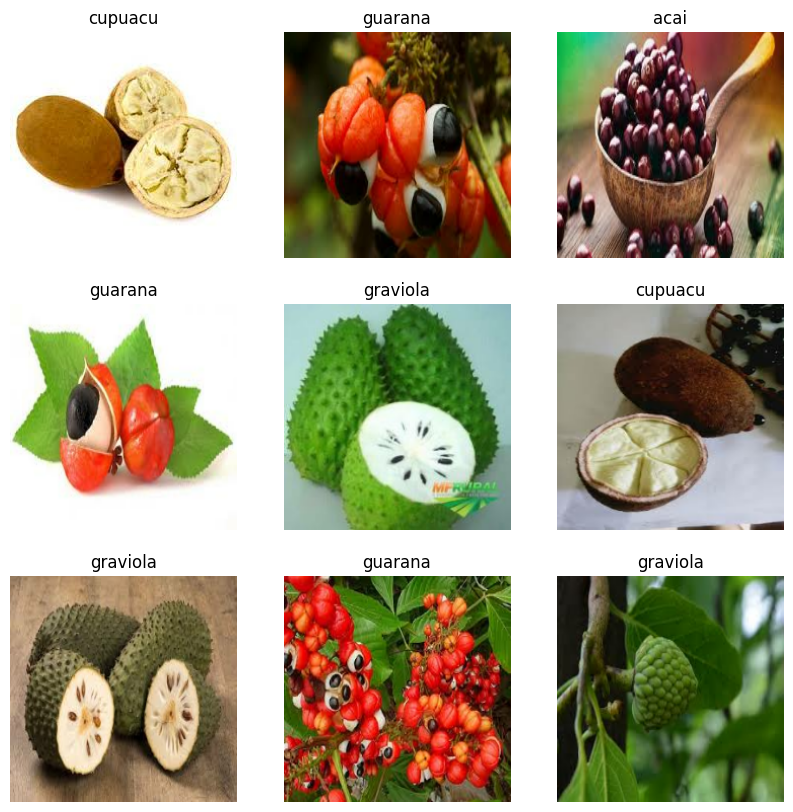

In [8]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

## Step 7: Apply Data Augmentation

Data augmentation increases the diversity of the training data by creating modified versions of the original images. This helps reduce overfitting and improves model generalization.

In [8]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

## Step 8: Visualize Augmented Images

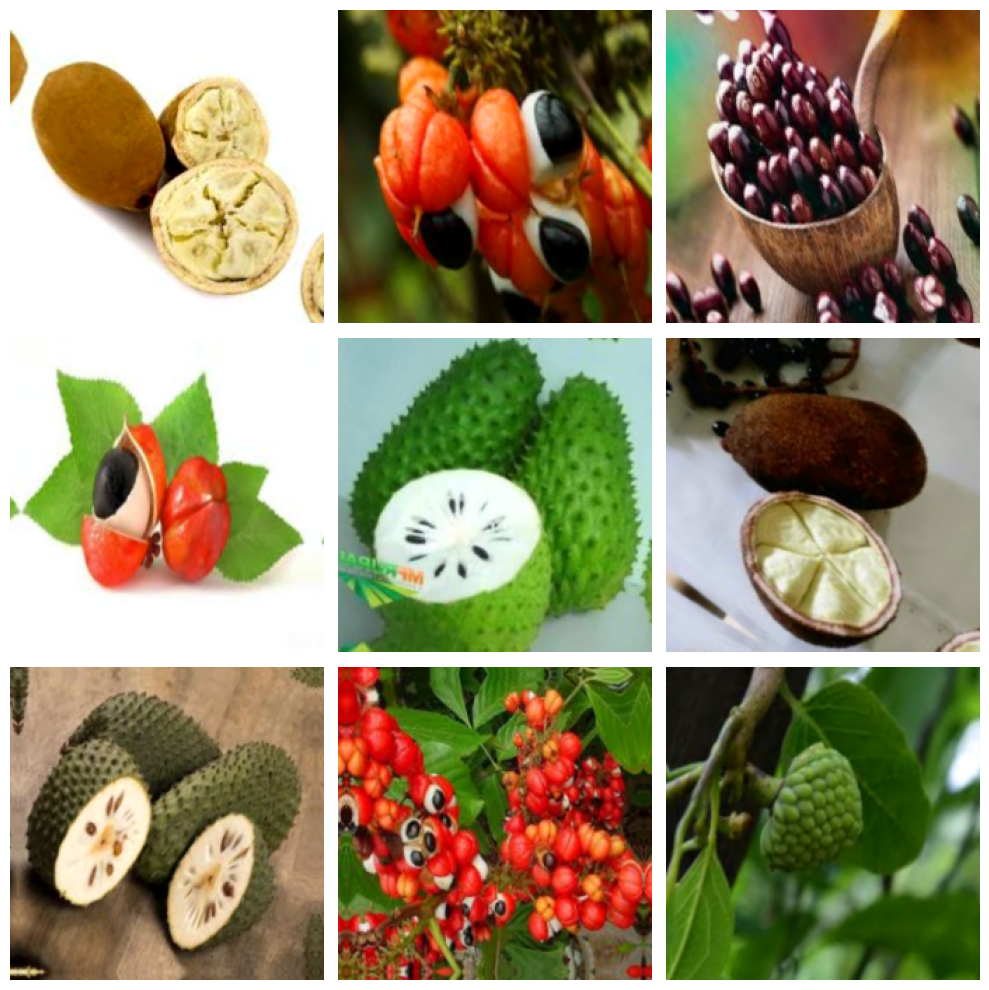

In [9]:
plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")
    break

plt.tight_layout()
plt.show()

## Step 9: Optimize Dataset Pipeline

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

## Step 10: Build an Improved CNN Model

Compared to the previous worksheet, this model is improved by:
- using data augmentation,
- scaling input data,
- adding Batch Normalization,
- adding Dropout,
- increasing model depth.

These improvements are expected to make training more stable and reduce overfitting.

In [11]:
scratch_model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, (3, 3), padding="same", activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding="same", activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), padding="same", activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3, 3), padding="same", activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(512, activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    layers.Dense(256, activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    layers.Dense(128, activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    layers.Dense(64, activation=None),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

scratch_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

## Step 11: Compile the Model

In [12]:
scratch_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Step 12: Train the Improved CNN Model

In [13]:
scratch_checkpoint_cb = ModelCheckpoint(
    "best_scratch_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

scratch_earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

scratch_history = scratch_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[scratch_checkpoint_cb, scratch_earlystop_cb]
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1017 - loss: 2.4496
Epoch 1: val_accuracy improved from -inf to 0.38889, saving model to best_scratch_cnn.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.1079 - loss: 2.4386 - val_accuracy: 0.3889 - val_loss: 1.7648
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1674 - loss: 2.2905
Epoch 2: val_accuracy did not improve from 0.38889
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.1834 - loss: 2.2716 - val_accuracy: 0.0556 - val_loss: 1.7464
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2688 - loss: 2.0630
Epoch 3: val_accuracy did not improve from 0.38889
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.2656 - loss: 2.0701 - val_accuracy: 0.1111 - val_loss: 1.7089
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1476 - loss: 2.1867
Epoch 4: val_accuracy did not improve from 0.38889
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.1461 - loss: 2.2094 - val_accuracy: 0.33

## Step 13: Plot Training and Validation Curves

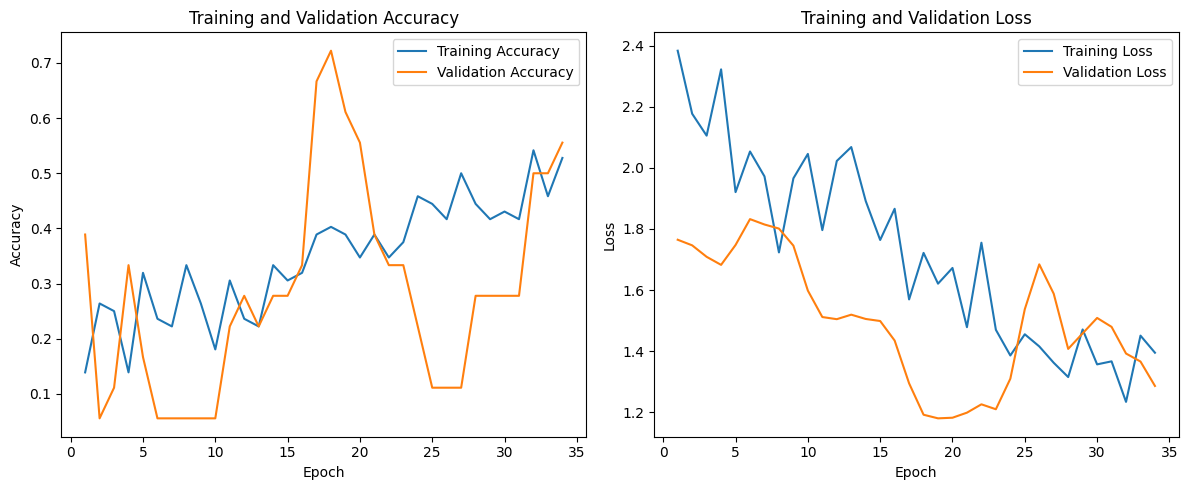

In [14]:
acc = scratch_history.history["accuracy"]
val_acc = scratch_history.history["val_accuracy"]
loss = scratch_history.history["loss"]
val_loss = scratch_history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Step 14: Evaluate the Improved CNN on the Test Set

In [15]:
scratch_test_loss, scratch_test_accuracy = scratch_model.evaluate(test_ds, verbose=1)

print(f"Scratch CNN Test Loss: {scratch_test_loss:.4f}")
print(f"Scratch CNN Test Accuracy: {scratch_test_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.2597 - loss: 1.9363
Scratch CNN Test Loss: 1.9000
Scratch CNN Test Accuracy: 0.2333


## Step 15: Generate Classification Report for the Improved CNN

In [16]:
scratch_y_true = []
scratch_y_pred = []

for images, labels in test_ds:
    preds = scratch_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    scratch_y_true.extend(labels.numpy())
    scratch_y_pred.extend(pred_labels)

scratch_y_true = np.array(scratch_y_true)
scratch_y_pred = np.array(scratch_y_pred)

print("Classification Report for Scratch CNN:\n")
print(classification_report(scratch_y_true, scratch_y_pred, target_names=class_names))

Classification Report for Scratch CNN:

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.25      1.00      0.40         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.20      0.40      0.27         5

    accuracy                           0.23        30
   macro avg       0.07      0.23      0.11        30
weighted avg       0.07      0.23      0.11        30



c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Acer\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

## Step 16: Confusion Matrix for the Improved CNN

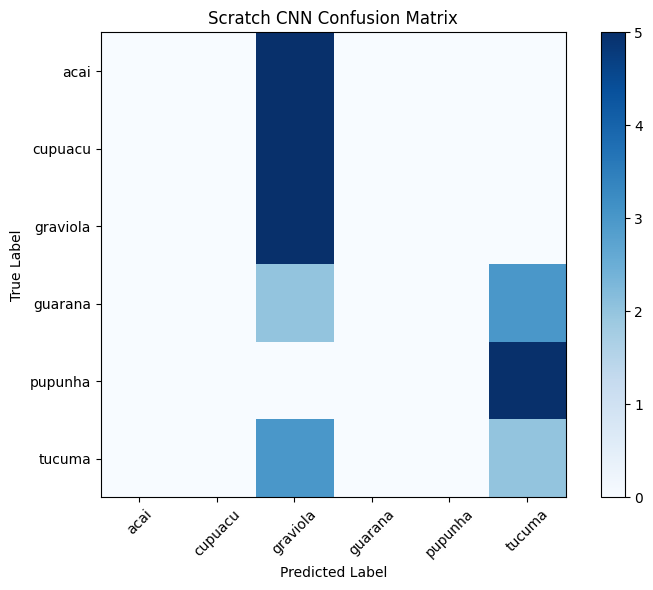

In [17]:
cm = confusion_matrix(scratch_y_true, scratch_y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Scratch CNN Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Task 2 - Transfer Learning with VGG16

In this section, transfer learning is implemented using the VGG16 model pre-trained on ImageNet. The convolutional base is frozen so that its pre-trained knowledge is preserved, and only the new classification head is trained on the fruits dataset.

In [18]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [19]:
vgg_train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="training",
    seed=seed,
    image_size=(224, 224),
    batch_size=batch_size,
    shuffle=True
)

vgg_val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=validation_split,
    subset="validation",
    seed=seed,
    image_size=(224, 224),
    batch_size=batch_size,
    shuffle=False
)

vgg_test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=batch_size,
    shuffle=False
)

class_names = vgg_train_ds.class_names
num_classes = len(class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


## Step 3: Preprocess Images for VGG16

VGG16 uses its own preprocessing function. Therefore, `preprocess_input()` is used instead of the normal rescaling layer.

In [20]:
vgg_data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="vgg_data_augmentation")

def prepare_for_vgg_train(x, y):
    x = tf.cast(x, tf.float32)
    x = vgg_data_augmentation(x, training=True)
    x = preprocess_input(x)
    return x, y

def prepare_for_vgg_eval(x, y):
    x = tf.cast(x, tf.float32)
    x = preprocess_input(x)
    return x, y

vgg_train_ds = vgg_train_ds.map(prepare_for_vgg_train)
vgg_val_ds = vgg_val_ds.map(prepare_for_vgg_eval)
vgg_test_ds = vgg_test_ds.map(prepare_for_vgg_eval)

vgg_train_ds = vgg_train_ds.prefetch(buffer_size=AUTOTUNE)
vgg_val_ds = vgg_val_ds.prefetch(buffer_size=AUTOTUNE)
vgg_test_ds = vgg_test_ds.prefetch(buffer_size=AUTOTUNE)

## Step 4: Load the Pre-trained VGG16 Base Model

In [21]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

## Step 5: Freeze the Base Model Layers

In [22]:
for layer in base_model.layers:
    layer.trainable = False

## Step 6: Add Custom Classification Layers

In [23]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation="relu")(x)
outputs = Dense(num_classes, activation="softmax")(x)

vgg_model = Model(inputs=base_model.input, outputs=outputs)

vgg_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,246,150 (58.16 MB)

 Trainable params: 531,462 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Step 7: Compile the VGG16 Model

In [24]:
vgg_model.compile(
    optimizer=Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Step 8: Train the Transfer Learning Model

In [25]:
vgg_checkpoint_cb = ModelCheckpoint(
    "best_vgg16_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

vgg_earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

vgg_history = vgg_model.fit(
    vgg_train_ds,
    validation_data=vgg_val_ds,
    epochs=30,
    callbacks=[vgg_checkpoint_cb, vgg_earlystop_cb]
)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3240 - loss: 3.2576
Epoch 1: val_accuracy improved from -inf to 0.77778, saving model to best_vgg16_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3394 - loss: 3.2577 - val_accuracy: 0.7778 - val_loss: 2.9172
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8983 - loss: 0.6867
Epoch 2: val_accuracy did not improve from 0.77778
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8921 - loss: 0.7362 - val_accuracy: 0.6667 - val_loss: 3.0765
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 968ms/step - accuracy: 0.9094 - loss: 0.2852
Epoch 3: val_accuracy improved from 0.77778 to 0.83333, saving model to best_vgg16_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9106 - loss: 0.2908 - val_accuracy: 0.8333 - val_loss: 3.1357
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 965ms/step - accuracy: 1.0000 - loss: 0.0012 
Epoch 4: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accur

## Step 9: Plot Training and Validation Curves for VGG16

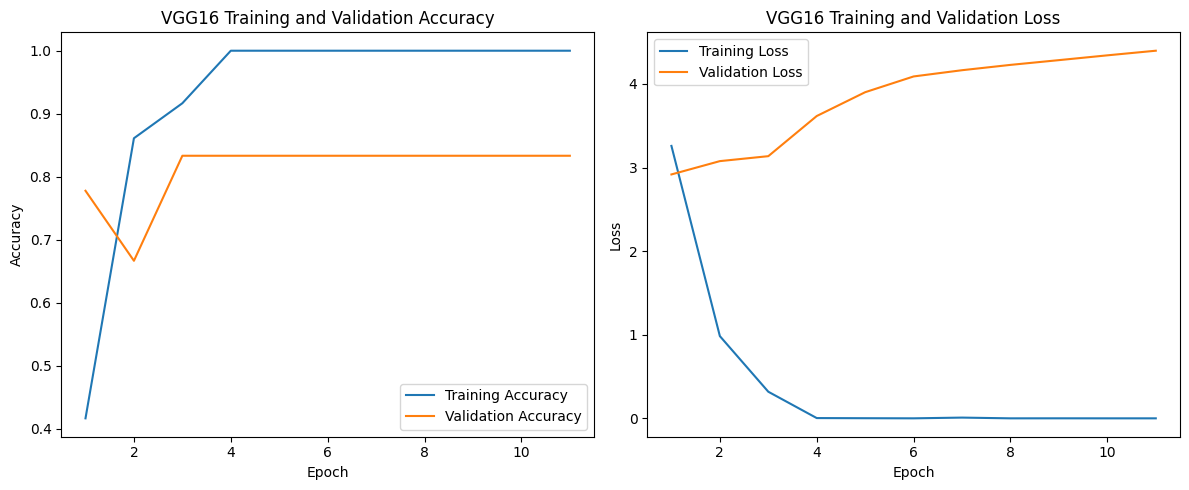

In [26]:
acc = vgg_history.history["accuracy"]
val_acc = vgg_history.history["val_accuracy"]
loss = vgg_history.history["loss"]
val_loss = vgg_history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("VGG16 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("VGG16 Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Step 10: Evaluate VGG16 on the Test Set

In [27]:
vgg_test_loss, vgg_test_accuracy = vgg_model.evaluate(vgg_test_ds, verbose=1)

print(f"VGG16 Test Loss: {vgg_test_loss:.4f}")
print(f"VGG16 Test Accuracy: {vgg_test_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 964ms/step - accuracy: 0.6944 - loss: 2.8618
VGG16 Test Loss: 3.4731
VGG16 Test Accuracy: 0.6667


## Step 11: Classification Report for VGG16

In [28]:
vgg_y_true = []
vgg_y_pred = []

for images, labels in vgg_test_ds:
    preds = vgg_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    vgg_y_true.extend(labels.numpy())
    vgg_y_pred.extend(pred_labels)

vgg_y_true = np.array(vgg_y_true)
vgg_y_pred = np.array(vgg_y_pred)

print("Classification Report for VGG16:\n")
print(classification_report(vgg_y_true, vgg_y_pred, target_names=class_names))

Classification Report for VGG16:

              precision    recall  f1-score   support

        acai       0.57      0.80      0.67         5
     cupuacu       1.00      0.40      0.57         5
    graviola       0.83      1.00      0.91         5
     guarana       0.80      0.80      0.80         5
     pupunha       0.50      0.40      0.44         5
      tucuma       0.50      0.60      0.55         5

    accuracy                           0.67        30
   macro avg       0.70      0.67      0.66        30
weighted avg       0.70      0.67      0.66        30



## Step 12: Inference Output

Found 30 files belonging to 6 classes.


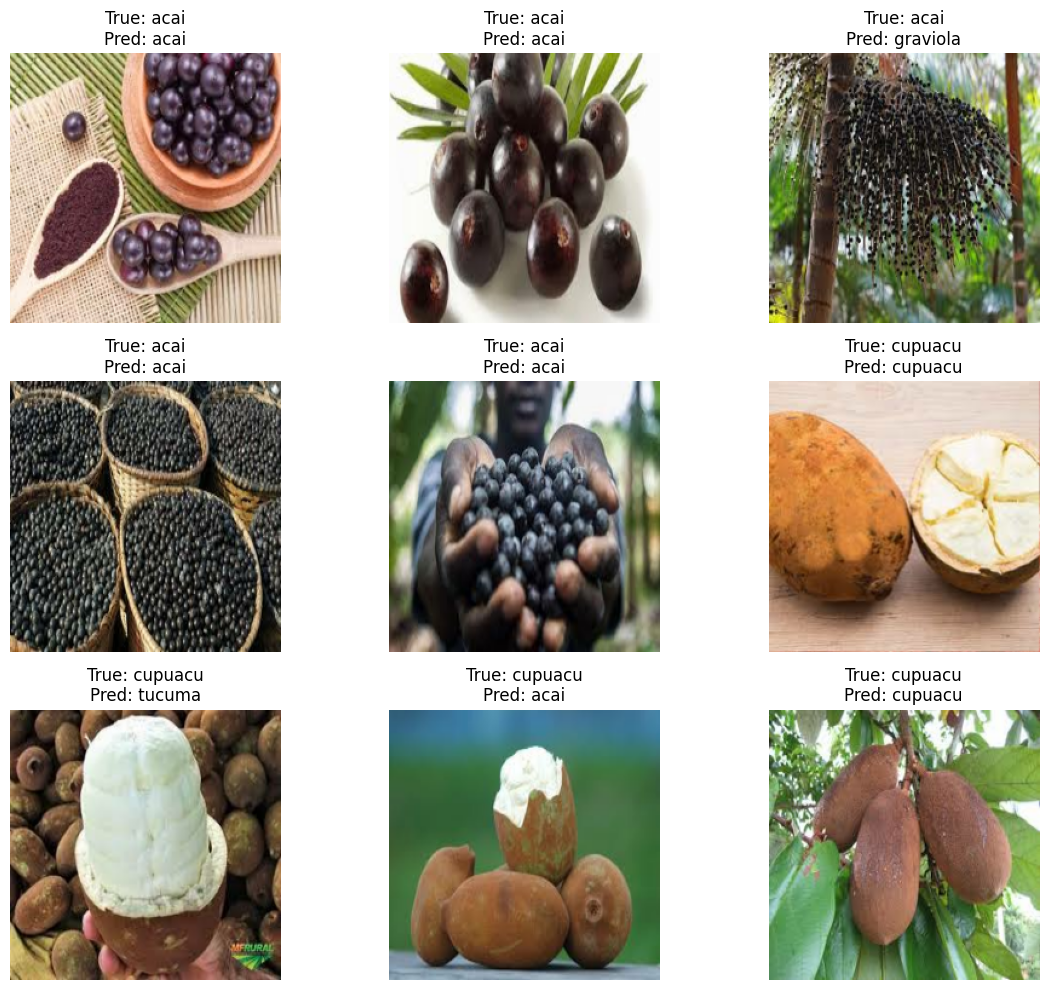

In [29]:
raw_test_preview = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=9,
    shuffle=False
)

for images, labels in raw_test_preview.take(1):
    prep_images = preprocess_input(tf.cast(images, tf.float32))
    preds = vgg_model.predict(prep_images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(12, 10))
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        true_label = class_names[labels[i].numpy()]
        pred_label = class_names[pred_labels[i]]
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Step 13: Compare the Two Models

In [30]:
print("Model Comparison")
print("=" * 40)
print(f"Scratch CNN Test Accuracy : {scratch_test_accuracy:.4f}")
print(f"VGG16 Test Accuracy       : {vgg_test_accuracy:.4f}")
print("=" * 40)

if vgg_test_accuracy > scratch_test_accuracy:
    print("Yes, transfer learning with VGG16 improved the performance.")
elif vgg_test_accuracy < scratch_test_accuracy:
    print("No, transfer learning with VGG16 did not improve the performance.")
else:
    print("Both models achieved the same accuracy.")

Model Comparison
Scratch CNN Test Accuracy : 0.2333
VGG16 Test Accuracy       : 0.6667
Yes, transfer learning with VGG16 improved the performance.


## Final Conclusion

In this worksheet, two image classification approaches were implemented using the FruitsInAmazon dataset.

First, an improved CNN model was built from scratch using data augmentation, batch normalization, and dropout. These additions helped improve the quality of training and reduce overfitting compared to a simple CNN.

Second, transfer learning was implemented using the VGG16 model pre-trained on ImageNet. The base layers were frozen and a custom classification head was added. The model was then trained on the fruits dataset and evaluated on the test set.

By comparing the test accuracies and classification reports of both models, it is possible to determine whether transfer learning improved performance. In most cases, transfer learning performs better on smaller datasets because it benefits from features learned from a large-scale dataset such as ImageNet.